In [75]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import folium

from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

In [76]:
# Load global charging stations dataset
global_stations_df = pd.read_csv('../Data/charging_station.csv')
print("Global stations shape:", global_stations_df.shape)
global_stations_df.head()

Global stations shape: (242417, 11)


,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,UNKNOWN,AD,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,UNKNOWN,AD,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,Unknown City,UNKNOWN,AD,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,Unknown City,UNKNOWN,AD,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,Unknown City,UNKNOWN,AD,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


In [77]:
# Check data types and missing values
global_stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            242417 non-null  object 
 3   state_province  242417 non-null  object 
 4   country_code    242417 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


In [78]:
# Examine unique country codes
global_stations_df['country_code'].unique()

array(['AD', 'AE', 'AF', 'AL', 'AM', 'AR', 'AT', 'AU', 'AX', 'AZ', 'BA',
       'BB', 'BE', 'BG', 'BH', 'BR', 'BW', 'BY', 'CA', 'CH', 'CL', 'CN',
       'CO', 'CR', 'CY', 'CZ', 'DE', 'DK', 'DO', 'EC', 'EE', 'EG', 'ES',
       'ET', 'FI', 'FO', 'FR', 'GB', 'GE', 'GG', 'GH', 'GI', 'GR', 'GT',
       'HK', 'HR', 'HU', 'ID', 'IE', 'IL', 'IM', 'IN', 'IQ', 'IS', 'IT',
       'JE', 'JM', 'JO', 'JP', 'KE', 'KG', 'KH', 'KR', 'KZ', 'LI', 'LK',
       'LT', 'LU', 'LV', 'MA', 'MC', 'MD', 'ME', 'MK', 'MM', 'MO', 'MT',
       'MX', 'MY', 'NAM', 'NL', 'NO', 'NP', 'NZ', 'OM', 'PA', 'PE', 'PH',
       'PK', 'PL', 'PR', 'PS', 'PT', 'PY', 'QA', 'RE', 'RO', 'RS', 'RU',
       'RW', 'SA', 'SE', 'SG', 'SI', 'SJ', 'SK', 'SM', 'SZ', 'TH', 'TN',
       'TR', 'TT', 'TW', 'UA', 'UG', 'US', 'UY', 'UZ', 'VN', 'XK', 'ZA'],
      dtype=object)

In [79]:
# Filter for Kenyan stations
kenya_stations1 = global_stations_df[global_stations_df['country_code'] == 'KE']
print("Kenyan stations from global dataset:", len(kenya_stations1))
kenya_stations1

Kenyan stations from global dataset: 12


,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False
128400,189880,Nopea JKIA Airport,Nairobi,Nairobi,KE,-1.333731,36.928334,1,22.0,AC_HIGH_(22-49kW),False
128401,175802,Two Rivers Mall Nairobi (Nopea),Nairobi,Nairobi,KE,-1.211449,36.795808,1,11.0,AC_L2_(7.5-21kW),False
128402,175801,Sarit Centre Nairobi,Nairobi,Nairobi,KE,-1.261245,36.802243,1,22.0,AC_HIGH_(22-49kW),False
128403,175800,TRM Mall,Nairobi,Nairobi,KE,-1.219824,36.889224,2,22.0,AC_HIGH_(22-49kW),False
128404,175799,Holy Family Basilica Parking Silo,Nairobi,Nairobi,KE,-1.287358,36.820061,1,11.0,AC_L2_(7.5-21kW),False


In [80]:
# Verify structure
kenya_stations1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 128395 to 128406
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              12 non-null     int64  
 1   name            12 non-null     object 
 2   city            12 non-null     object 
 3   state_province  12 non-null     object 
 4   country_code    12 non-null     object 
 5   latitude        12 non-null     float64
 6   longitude       12 non-null     float64
 7   ports           12 non-null     int64  
 8   power_kw        12 non-null     float64
 9   power_class     12 non-null     object 
 10  is_fast_dc      12 non-null     bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 1.0+ KB


In [81]:
# Load Kenya-specific dataset
kenya_stations2 = pd.read_csv('../Data/kenya_ev_charging_stations_sample_new.csv')
print("Kenya-specific stations shape:", kenya_stations2.shape)
kenya_stations2

Kenya-specific stations shape: (16, 6)


,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790
5,Nairobi,Britam Towers Upper Hill,AC,Type2,-1.299760,36.813140
6,Nairobi,Movenpick Westlands,AC,Type2,-1.261070,36.804990
7,Nairobi,Stima Plaza,AC/DC,Mixed,-1.271410,36.820530
8,Nairobi,Ruaraka KPLC,AC/DC,Mixed,-1.259280,36.859540
9,Nakuru,Westside Mall,AC,Type2,-0.287090,36.063930


In [82]:
# Examine structure
kenya_stations2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   County/City      16 non-null     object 
 1   Station Name     16 non-null     object 
 2   Charger Type     16 non-null     object 
 3   Connector Types  16 non-null     object 
 4   Latitude         16 non-null     float64
 5   Longitude        16 non-null     float64
dtypes: float64(2), object(4)
memory usage: 896.0+ bytes


In [83]:
# Load population data
kenyan_population_df = pd.read_csv('../Data/kenya-population-distibution-2019-census.csv')
print("Population data shape:", kenyan_population_df.shape)
kenyan_population_df.head()

Population data shape: (48, 5)


,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1


In [84]:
# Check data types
kenyan_population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   County    48 non-null     object
 1   Total     48 non-null     object
 2   Male      48 non-null     object
 3   Female    48 non-null     object
 4   Intersex  48 non-null     object
dtypes: object(5)
memory usage: 2.0+ KB


In [85]:
# Load boundaries data
ken_boundaries_df = pd.read_excel('../Data/ken_adminboundaries_tabulardata.xlsx')
print("Boundaries data shape:", ken_boundaries_df.shape)
ken_boundaries_df.head()

Boundaries data shape: (290, 16)


,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [86]:
# Examine structure
ken_boundaries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECTID *         290 non-null    int64         
 1   Shape *            290 non-null    object        
 2   admin2Name_en      290 non-null    object        
 3   admin2Pcode        290 non-null    object        
 4   admin2RefName      290 non-null    object        
 5   admin2AltName1_en  290 non-null    object        
 6   admin2AltName2_en  290 non-null    object        
 7   admin1Name_en      290 non-null    object        
 8   admin1Pcode        290 non-null    object        
 9   admin0Name_en      290 non-null    object        
 10  admin0Pcode        290 non-null    object        
 11  date               290 non-null    datetime64[ns]
 12  validOn            290 non-null    datetime64[ns]
 13  validTo            290 non-null    object        
 14  Shape_Leng

In [87]:
# Load county coordinates
county_coords = pd.read_csv("../Data/county_coordinates.csv")
print("County coordinates shape:", county_coords.shape)
county_coords.head()

County coordinates shape: (47, 3)


,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.283300
1,Kericho,-0.367740,35.283140
2,Nandi,0.166667,35.150000
3,Siaya,-0.083333,34.249999
4,Nakuru,-0.283332,36.066666


In [88]:
# Check structure
county_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   county     47 non-null     object 
 1   Latitude   47 non-null     float64
 2   Longitude  47 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


In [89]:
# Check for duplicates and missing values in all datasets
print("=== GLOBAL STATIONS DATASET ===")
print("Duplicates:", kenya_stations1.duplicated().sum())
print("Missing values:\n", kenya_stations1.isnull().sum())

print("\n=== KENYA STATIONS DATASET ===")
print("Duplicates:", kenya_stations2.duplicated().sum())
print("Missing values:\n", kenya_stations2.isnull().sum())

print("\n=== POPULATION DATASET ===")
print("Duplicates:", kenyan_population_df.duplicated().sum())
print("Missing values:\n", kenyan_population_df.isnull().sum())

print("\n=== BOUNDARIES DATASET ===")
print("Duplicates:", ken_boundaries_df.duplicated().sum())
print("Missing values:\n", ken_boundaries_df.isnull().sum())

print("\n=== COUNTY COORDINATES DATASET ===")
print("Duplicates:", county_coords.duplicated().sum())
print("Missing values:\n", county_coords.isnull().sum())

=== GLOBAL STATIONS DATASET ===
Duplicates: 0
Missing values:
 id                0
name              0
city              0
state_province    0
country_code      0
latitude          0
longitude         0
ports             0
power_kw          0
power_class       0
is_fast_dc        0
dtype: int64

=== KENYA STATIONS DATASET ===
Duplicates: 0
Missing values:
 County/City        0
Station Name       0
Charger Type       0
Connector Types    0
Latitude           0
Longitude          0
dtype: int64

=== POPULATION DATASET ===
Duplicates: 0
Missing values:
 County      0
Total       0
Male        0
Female      0
Intersex    0
dtype: int64

=== BOUNDARIES DATASET ===
Duplicates: 0
Missing values:
 OBJECTID *           0
Shape *              0
admin2Name_en        0
admin2Pcode          0
admin2RefName        0
admin2AltName1_en    0
admin2AltName2_en    0
admin1Name_en        0
admin1Pcode          0
admin0Name_en        0
admin0Pcode          0
date                 0
validOn              0
va

In [90]:
# Preview before cleaning
kenya_stations1.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False


In [91]:
# Remove unnecessary columns
kenya_stations1 = kenya_stations1.drop(columns=['id', 'city', 'is_fast_dc'])
kenya_stations1.head()

,name,state_province,country_code,latitude,longitude,ports,power_kw,power_class
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW)
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW)
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW)
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW)
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW)


In [92]:
# Rename columns for consistency
kenya_stations1 = kenya_stations1.rename(columns={
    "state_province": "county", 
    "name": "station name"
})

In [93]:
# Check distribution by county
kenya_stations1['county'].value_counts()

county
Nairobi    11
Mombasa     1
Name: count, dtype: int64

In [94]:
# Extract charger type
kenya_stations1["charger type"] = kenya_stations1["power_class"].str.split("_").str[0].str.upper()

In [95]:
# Drop redundant columns
kenya_stations1 = kenya_stations1.drop(columns=["power_class", "power_kw"])
kenya_stations1.head()

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,AC
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,AC
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,AC


In [96]:
# Preview
kenya_stations2.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [97]:
# Remove Connector Types column
kenya_stations2 = kenya_stations2.drop(columns='Connector Types')

In [98]:
# Rename columns
kenya_stations2 = kenya_stations2.rename(columns={
    "County/City": "county", 
    "Station Name": "station name", 
    "Charger Type": "charger type", 
    "Latitude": "latitude", 
    "Longitude": "longitude"
})

In [99]:
# Check distribution
kenya_stations2['county'].value_counts()

county
Nairobi     9
Nakuru      1
Naivasha    1
Kiambu      1
Kisumu      1
Mombasa     1
Narok       1
Mavoko      1
Name: count, dtype: int64

In [100]:
# Standardize county names
kenya_stations2['county'] = kenya_stations2['county'].replace(
    ['Mavoko', 'Naivasha'], ['Machakos', 'Nakuru']
)
kenya_stations2['county'].value_counts()

county
Nairobi     9
Nakuru      2
Kiambu      1
Kisumu      1
Mombasa     1
Narok       1
Machakos    1
Name: count, dtype: int64

In [101]:
# Preview cleaned dataset
kenya_stations2.head()

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,-1.301320,36.812790


In [102]:
# Display full dataset
kenyan_population_df

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1
5,Lamu,"38,446","19,533","18,911",2
6,Taita/Taveta,"93,774","46,620","47,149",5
7,Garissa,"210,890","109,552","101,331",7
8,Wajir,"177,174","94,812","82,340",22
9,Mandera,"270,467","135,548","134,909",10


In [103]:
# Remove gender columns
kenyan_population_df = kenyan_population_df.drop(columns=['Male', 'Female', 'Intersex'])

In [104]:
# Rename columns
kenyan_population_df = kenyan_population_df.rename(columns={"County": "county", "Total": "population"})

In [105]:
# Remove 'KENYA' summary row
kenyan_population_df = kenyan_population_df[kenyan_population_df['county'] != 'KENYA']

In [106]:
# Standardize county names
kenyan_population_df['county'] = kenyan_population_df['county'].replace(
    ['Nairobi City', 'Elg eyo/Marakwet', 'Taita/Taveta'], 
    ['Nairobi', 'Elgeyo-Marakwet', 'Taita Taveta']
)

In [107]:
# Convert population to integers
kenyan_population_df['population'] = kenyan_population_df['population'].str.replace(',', '').astype(int)
kenyan_population_df.head(2)

,county,population
1,Mombasa,1208333
2,Kwale,126431


In [108]:
# Preview
ken_boundaries_df.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [109]:
# Rename columns
ken_boundaries_df = ken_boundaries_df.rename(columns={
    "admin1Name_en": "county",
    "admin2Name_en": "sub county", 
    "admin0Pcode": "country code", 
    "Shape_Area": "shape area", 
    "Shape_Length": "shape length"
})

In [110]:
# Select relevant columns
ken_boundaries_df = ken_boundaries_df[['county', 'sub county', 'country code', 'shape area', 'shape length']]
ken_boundaries_df

,county,sub county,country code,shape area,shape length
0,Uasin Gishu,Ainabkoi,KE,0.040829,1.746986
1,Kericho,Ainamoi,KE,0.019957,0.917307
2,Nandi,Aldai,KE,0.038000,1.402637
3,Siaya,Alego Usonga,KE,0.049357,1.081354
4,Migori,Awendo,KE,0.021365,0.743915
...,...,...,...,...,...
285,Bungoma,Webuye West,KE,0.019180,1.010876
286,Nyamira,West Mugirango,KE,0.014610,0.630183
287,Nairobi,Westlands,KE,0.005908,0.405298
288,Taita Taveta,Wundanyi,KE,0.069243,1.214526


In [111]:
# Preview
county_coords.head(2)

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


In [112]:
# Rename columns
county_coords = county_coords.rename(columns={"Latitude": "county_lat", "Longitude": "county_lon"})
county_coords.head(2)

,county,county_lat,county_lon
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


In [113]:
# Combine both station datasets
kenya_stations = pd.concat([kenya_stations1, kenya_stations2], ignore_index=True)
print("Combined stations:", len(kenya_stations))
kenya_stations

Combined stations: 28


,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [114]:
# Remove duplicates based on coordinates
kenya_stations = kenya_stations.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
print("After removing duplicates:", len(kenya_stations))
kenya_stations

After removing duplicates: 24


,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [115]:
# Check missing values
kenya_stations.isnull().sum()

station name     0
county           0
country_code    12
latitude         0
longitude        0
ports           12
charger type     0
dtype: int64

In [116]:
# Fill missing values
kenya_stations['country_code'] = kenya_stations['country_code'].fillna('KE')
kenya_stations['ports'] = kenya_stations['ports'].fillna(1.0)
kenya_stations.isnull().sum()

station name    0
county          0
country_code    0
latitude        0
longitude       0
ports           0
charger type    0
dtype: int64

In [117]:
# Final stations dataframe
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [118]:
# Merge population with county coordinates
county_df = kenyan_population_df.merge(county_coords, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon
0,Mombasa,1208333,-4.054660,39.663590
1,Kwale,126431,-4.171333,39.456164
2,Kilifi,393888,-3.666670,39.750000
3,Tana River,75722,-1.533330,39.416670
4,Lamu,38446,-2.271690,40.902010


In [119]:
# Calculate station counts per county
station_counts = kenya_stations.groupby('county').size().reset_index(name='num_stations')
station_counts

,county,num_stations
0,Kiambu,1
1,Kisumu,1
2,Machakos,1
3,Mombasa,1
4,Nairobi,17
5,Nakuru,2
6,Narok,1


In [120]:
# Merge station counts
county_df = county_df.merge(station_counts, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,NaN
2,Kilifi,393888,-3.666670,39.750000,NaN
3,Tana River,75722,-1.533330,39.416670,NaN
4,Lamu,38446,-2.271690,40.902010,NaN


In [121]:
# Fill missing station counts with 0
county_df['num_stations'] = county_df['num_stations'].fillna(0)
county_df.head(15)

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,0.0
2,Kilifi,393888,-3.666670,39.750000,0.0
3,Tana River,75722,-1.533330,39.416670,0.0
4,Lamu,38446,-2.271690,40.902010,0.0
5,Taita Taveta,93774,-3.333332,38.249999,0.0
6,Garissa,210890,-0.452750,39.646010,0.0
7,Wajir,177174,1.747220,40.068900,0.0
8,Mandera,270467,3.416670,40.666700,0.0
9,Marsabit,107239,2.328390,37.989860,0.0


In [122]:
# Calculate total area per county
county_area = ken_boundaries_df.groupby("county", as_index=False)["shape area"].sum()
county_area.head()

,county,shape area
0,Baringo,0.884732
1,Bomet,0.198098
2,Bungoma,0.245060
3,Busia,0.147178
4,Elgeyo-Marakwet,0.244432


In [123]:
# Merge area data
county_df = county_df.merge(county_area[['county', 'shape area']], on='county', how='left')
county_df

,county,population,county_lat,county_lon,num_stations,shape area
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574
5,Taita Taveta,93774,-3.333332,38.249999,0.0,1.394198
6,Garissa,210890,-0.452750,39.646010,0.0,3.542187
7,Wajir,177174,1.747220,40.068900,0.0,4.606490
8,Mandera,270467,3.416670,40.666700,0.0,2.114345
9,Marsabit,107239,2.328390,37.989860,0.0,6.185190


Total stations: 24
Valid coordinates: 24
Invalid coordinates: 0


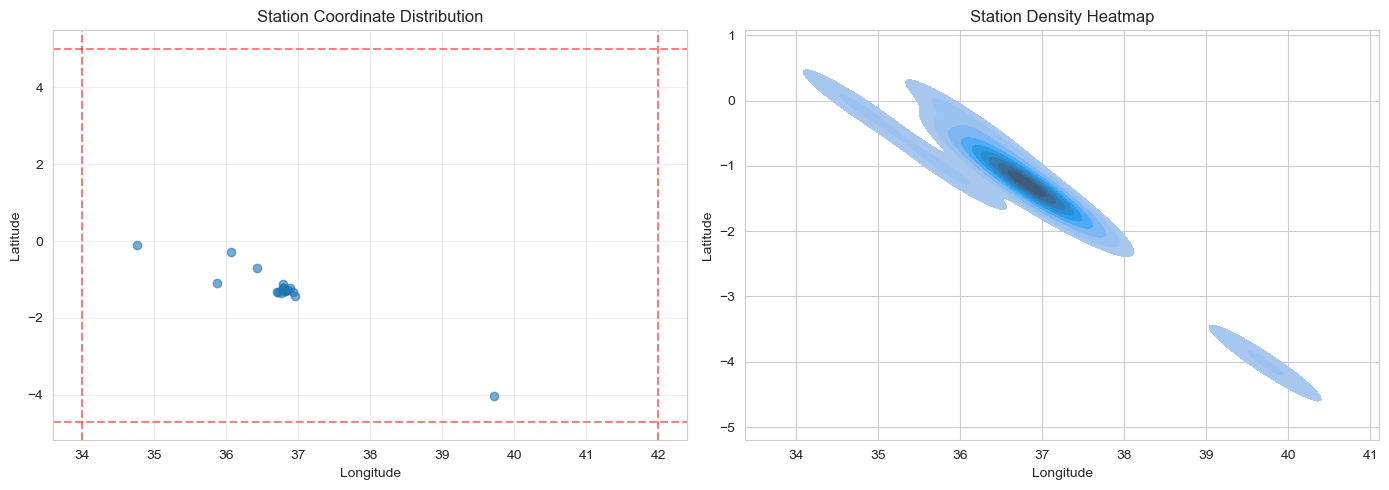

In [124]:
"""
Check if station coordinates fall within Kenya's approximate boundaries
"""

# Kenya approximate bounding box
kenya_bounds = {
    'lat_min': -4.7, 'lat_max': 5.0,
    'lon_min': 34.0, 'lon_max': 42.0
}

# Validate coordinates
valid_coords = (
    (kenya_stations['latitude'].between(kenya_bounds['lat_min'], kenya_bounds['lat_max'])) &
    (kenya_stations['longitude'].between(kenya_bounds['lon_min'], kenya_bounds['lon_max']))
)

print(f"Total stations: {len(kenya_stations)}")
print(f"Valid coordinates: {valid_coords.sum()}")
print(f"Invalid coordinates: {(~valid_coords).sum()}")

if (~valid_coords).sum() > 0:
    print("\nStations with potentially invalid coordinates:")
    print(kenya_stations[~valid_coords][['station name', 'county', 'latitude', 'longitude']])

# Visualize coordinate distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(kenya_stations['longitude'], kenya_stations['latitude'], alpha=0.6)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('Station Coordinate Distribution')
axes[0].grid(True, alpha=0.3)

# Add Kenya bounds rectangle
axes[0].axvline(x=kenya_bounds['lon_min'], color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=kenya_bounds['lon_max'], color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=kenya_bounds['lat_min'], color='r', linestyle='--', alpha=0.5)
axes[0].axhline(y=kenya_bounds['lat_max'], color='r', linestyle='--', alpha=0.5)

sns.kdeplot(x=kenya_stations['longitude'], y=kenya_stations['latitude'], 
            fill=True, ax=axes[1])
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Station Density Heatmap')

plt.tight_layout()
plt.show()

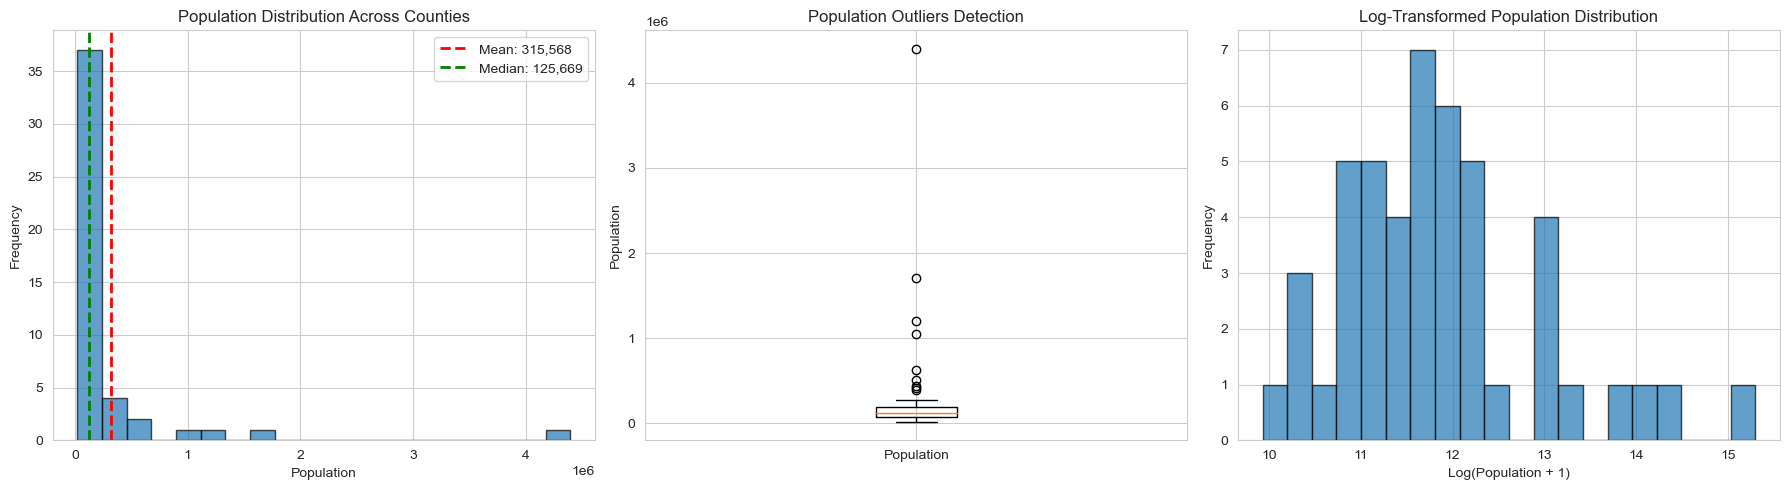

POPULATION STATISTICS
Mean: 315,568
Median: 125,669
Std Dev: 689,268
Skewness: 4.95
Kurtosis: 27.77

COUNTIES DOMINATING THE MODEL (Population > 2M)
 county  population
Nairobi     4397073

INTERPRETATION

- High positive skewness (4.95) indicates Nairobi dominates the distribution
- The model may be biased towards high-population counties
- Consider:
  1. Using log transformation for features
  2. Applying sample weights inversely proportional to population
  3. Stratified sampling for train-test split



In [125]:
"""
Analyze population distribution across counties to identify model bias risks
"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(county_df['population'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(county_df['population'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {county_df["population"].mean():,.0f}')
axes[0].axvline(county_df['population'].median(), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {county_df["population"].median():,.0f}')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Population Distribution Across Counties')
axes[0].legend()

# Box plot
axes[1].boxplot(county_df['population'])
axes[1].set_ylabel('Population')
axes[1].set_title('Population Outliers Detection')
axes[1].set_xticklabels(['Population'])

# Log-transformed histogram
log_pop = np.log1p(county_df['population'])
axes[2].hist(log_pop, bins=20, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Log(Population + 1)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed Population Distribution')

plt.tight_layout()
plt.show()

print("=" * 60)
print("POPULATION STATISTICS")
print("=" * 60)
print(f"Mean: {county_df['population'].mean():,.0f}")
print(f"Median: {county_df['population'].median():,.0f}")
print(f"Std Dev: {county_df['population'].std():,.0f}")
print(f"Skewness: {county_df['population'].skew():.2f}")
print(f"Kurtosis: {county_df['population'].kurtosis():.2f}")

print("\n" + "=" * 60)
print("COUNTIES DOMINATING THE MODEL (Population > 2M)")
print("=" * 60)
dominant_counties = county_df[county_df['population'] > 2000000][['county', 'population']].sort_values('population', ascending=False)
print(dominant_counties.to_string(index=False))

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print("""
- High positive skewness ({:.2f}) indicates Nairobi dominates the distribution
- The model may be biased towards high-population counties
- Consider:
  1. Using log transformation for features
  2. Applying sample weights inversely proportional to population
  3. Stratified sampling for train-test split
""".format(county_df['population'].skew()))

✓ Population density calculated
✓ Stations per 100k population calculated
✓ Population per station calculated
✓ Station spatial density calculated
✓ Urban indicator created (threshold: 7.74e+05)
✓ Population quintile created
✓ Coverage deficit calculated

FEATURE STATISTICS SUMMARY
       population_density  stations_per_100k  population_per_station  \
count        4.700000e+01          47.000000                    47.0   
mean         3.569807e+06           0.046464                     inf   
std          1.427330e+07           0.161349                     NaN   
min          1.733803e+04           0.000000                100352.0   
25%          8.464460e+04           0.000000                     NaN   
50%          2.941365e+05           0.000000                     NaN   
75%          7.743357e+05           0.000000                     NaN   
max          7.647748e+07           0.996492                     inf   

       station_spatial_density  
count                47.000000  
me

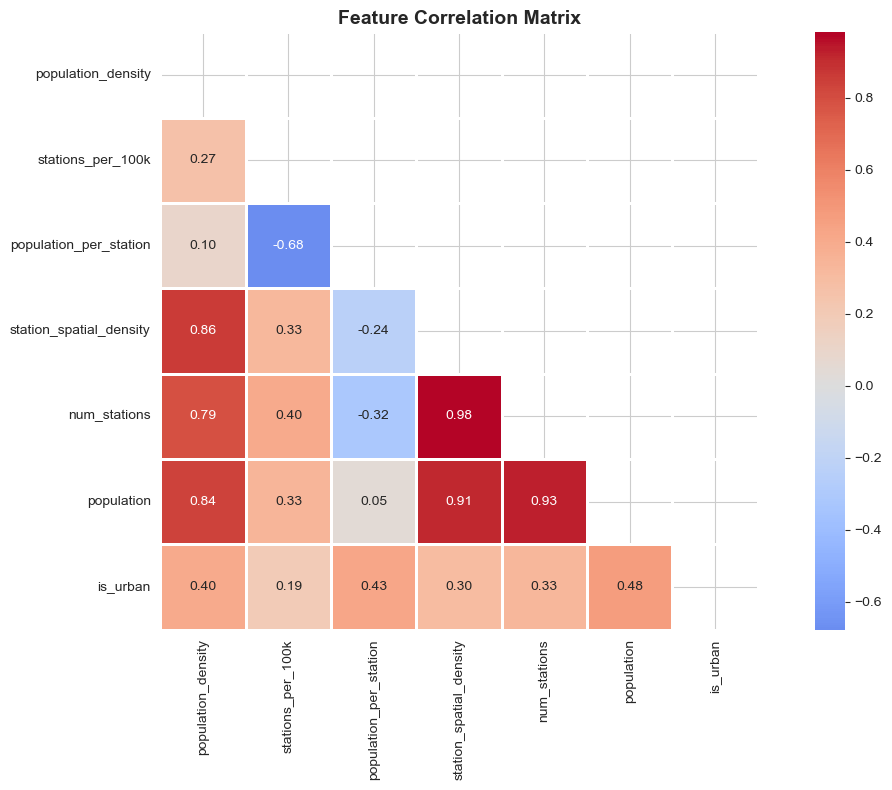


FEATURE ENGINEERING RATIONALE

- **population_density**: Denser areas need more stations (people per km²)
- **stations_per_100k**: Normalized infrastructure measure (international benchmark)
- **population_per_station**: Service coverage metric (∞ indicates no service)
- **station_spatial_density**: Geographic infrastructure density (stations per km²)
- **is_urban**: Binary indicator for urban/rural classification
- **coverage_deficit**: Direct measure of infrastructure gap



In [126]:
"""
Creating derived features with business context for modeling
"""

# Calculate population density
county_df['population_density'] = county_df['population'] / county_df['shape area']
print("✓ Population density calculated")

# Calculate stations per 100,000 people
county_df['stations_per_100k'] = (county_df['num_stations'] / county_df['population']) * 100000
print("✓ Stations per 100k population calculated")

# Calculate population per station (handle zero stations)
county_df['population_per_station'] = np.where(
    county_df['num_stations'] > 0,
    county_df['population'] / county_df['num_stations'],
    np.inf  # Infinite for counties with no stations
)
print("✓ Population per station calculated")

# Calculate station spatial density
county_df['station_spatial_density'] = county_df['num_stations'] / county_df['shape area']
print("✓ Station spatial density calculated")

# Urban indicator (based on population density threshold)
density_threshold = county_df['population_density'].quantile(0.75)
county_df['is_urban'] = (county_df['population_density'] > density_threshold).astype(int)
print(f"✓ Urban indicator created (threshold: {density_threshold:.2e})")

# Population quintile (for stratified analysis)
county_df['population_quintile'] = pd.qcut(county_df['population'], q=5, labels=False) + 1
print("✓ Population quintile created")

# Calculate coverage deficit
target_ratio = 200000  # Target population per station
county_df['coverage_deficit'] = np.maximum(
    0,
    (county_df['population'] / target_ratio) - county_df['num_stations']
)
print("✓ Coverage deficit calculated")

# Calculate required stations based on threshold
county_df["required_stations"] = np.ceil(county_df["population"] / 200000)
county_df["required_stations"] = county_df["required_stations"].apply(lambda x: max(1, x))

# Calculate additional stations needed
county_df["additional_stations"] = county_df["required_stations"] - county_df["num_stations"]
county_df["additional_stations"] = county_df["additional_stations"].apply(lambda x: max(0, x))

print("\n" + "=" * 60)
print("FEATURE STATISTICS SUMMARY")
print("=" * 60)
feature_stats = county_df[['population_density', 'stations_per_100k', 
                          'population_per_station', 'station_spatial_density']].describe()
print(feature_stats)

# Correlation heatmap of features
plt.figure(figsize=(12, 8))
feature_corr = county_df[['population_density', 'stations_per_100k', 
                         'population_per_station', 'station_spatial_density',
                         'num_stations', 'population', 'is_urban']].corr()

# Mask for upper triangle
mask = np.triu(np.ones_like(feature_corr, dtype=bool))
sns.heatmap(feature_corr, mask=mask, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FEATURE ENGINEERING RATIONALE")
print("=" + "=" * 60)
print("""
- **population_density**: Denser areas need more stations (people per km²)
- **stations_per_100k**: Normalized infrastructure measure (international benchmark)
- **population_per_station**: Service coverage metric (∞ indicates no service)
- **station_spatial_density**: Geographic infrastructure density (stations per km²)
- **is_urban**: Binary indicator for urban/rural classification
- **coverage_deficit**: Direct measure of infrastructure gap
""")

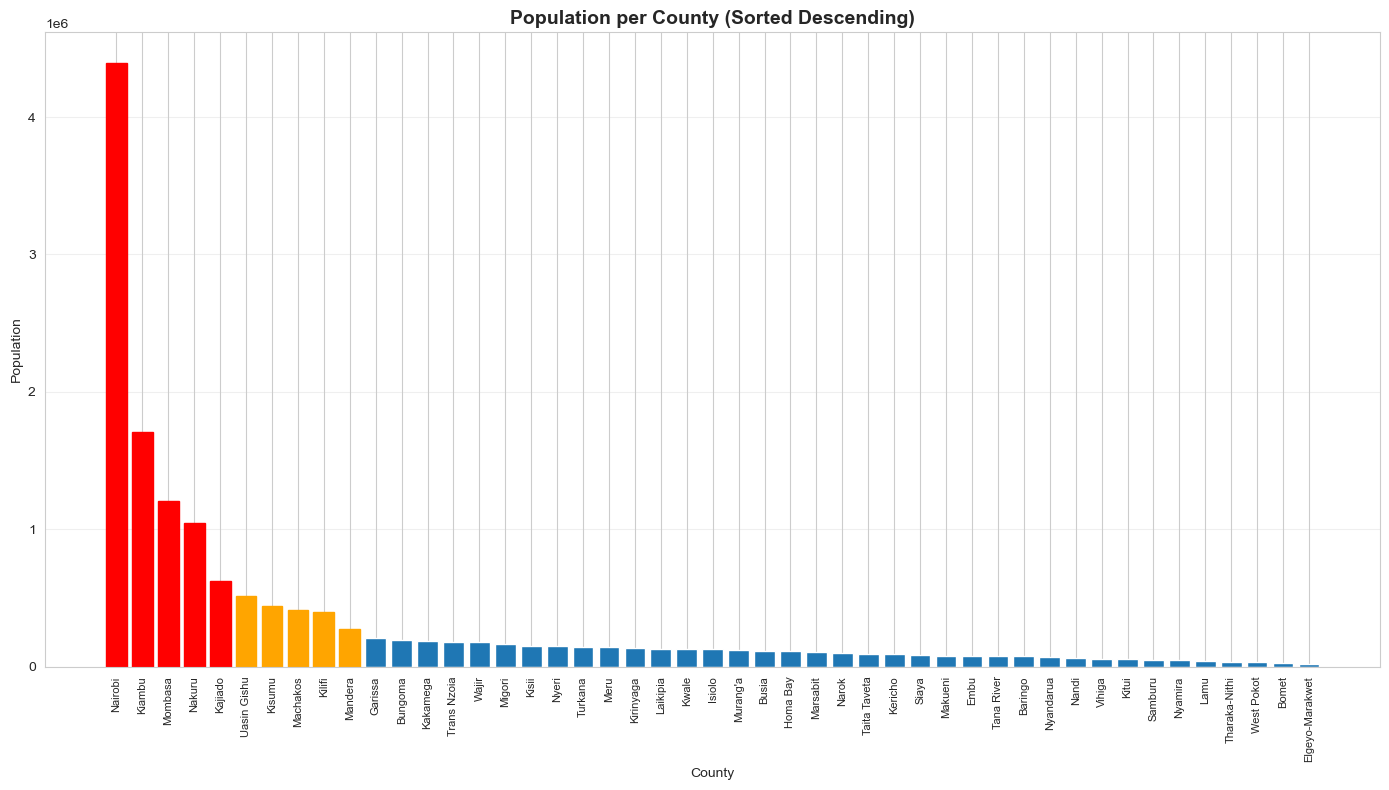

In [127]:
# Bar chart of population
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(county_df)), county_df['population'].sort_values(ascending=False))
plt.xticks(range(len(county_df)), county_df.sort_values('population', ascending=False)['county'], 
           rotation=90, fontsize=8)
plt.title("Population per County (Sorted Descending)", fontsize=14, fontweight='bold')
plt.xlabel("County")
plt.ylabel("Population")
plt.grid(axis='y', alpha=0.3)

# Color the top 5 counties differently
for i in range(5):
    bars[i].set_color('red')
for i in range(5, 10):
    bars[i].set_color('orange')

plt.tight_layout()
plt.show()

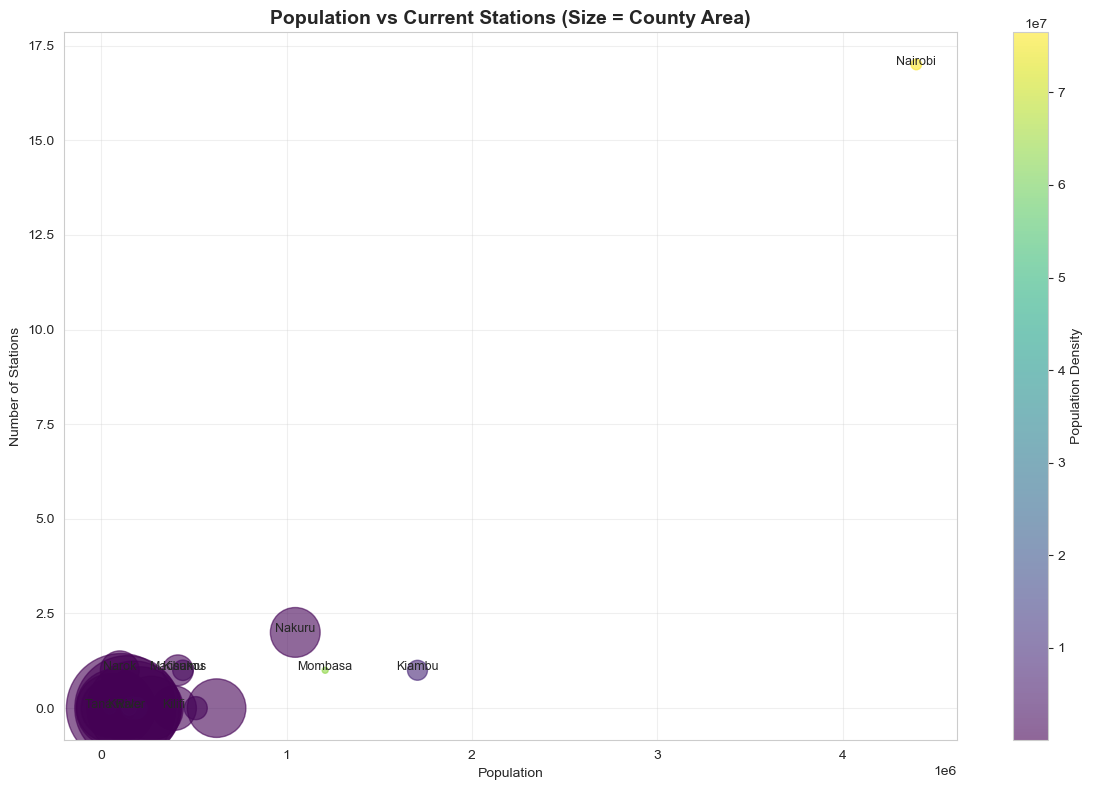

Correlation between population and stations: 0.926


In [128]:
plt.figure(figsize=(12, 8))

# Scatter plot with size representing area
scatter = plt.scatter(county_df["population"], county_df["num_stations"], 
                      s=county_df["shape area"] * 1000, alpha=0.6, 
                      c=county_df["population_density"], cmap='viridis')

# Add county labels for top stations
top_counties = county_df.nlargest(10, 'num_stations')
for _, row in top_counties.iterrows():
    plt.annotate(row['county'], (row['population'], row['num_stations']), 
                 fontsize=9, ha='center')

plt.colorbar(scatter, label='Population Density')
plt.xlabel("Population")
plt.ylabel("Number of Stations")
plt.title("Population vs Current Stations (Size = County Area)", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
corr = county_df[['population', 'num_stations']].corr().iloc[0,1]
print(f"Correlation between population and stations: {corr:.3f}")

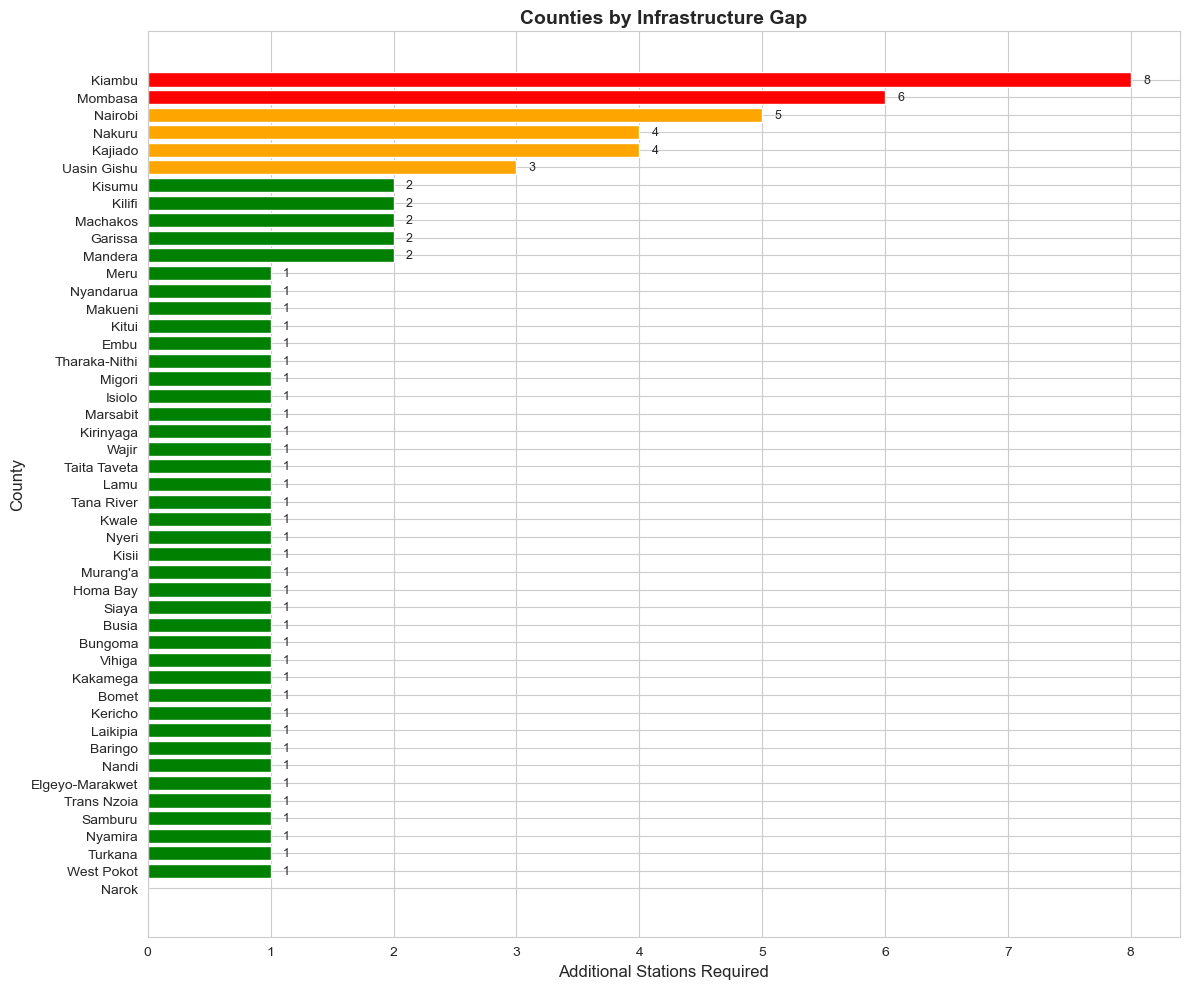

TOP 10 COUNTIES REQUIRING STATIONS
     county  num_stations  required_stations  additional_stations
     Kiambu           1.0                9.0                  8.0
    Mombasa           1.0                7.0                  6.0
    Nairobi          17.0               22.0                  5.0
     Nakuru           2.0                6.0                  4.0
    Kajiado           0.0                4.0                  4.0
Uasin Gishu           0.0                3.0                  3.0
   Machakos           1.0                3.0                  2.0
    Garissa           0.0                2.0                  2.0
    Mandera           0.0                2.0                  2.0
     Kilifi           0.0                2.0                  2.0


In [129]:
# Sort counties by additional stations needed
gap = county_df.sort_values("additional_stations", ascending=True)

plt.figure(figsize=(12, 10))
colors = ['red' if x > 5 else 'orange' if x > 2 else 'green' for x in gap['additional_stations']]
plt.barh(gap["county"], gap["additional_stations"], color=colors)
plt.xlabel("Additional Stations Required", fontsize=12)
plt.ylabel("County", fontsize=12)
plt.title("Counties by Infrastructure Gap", fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(gap.iterrows()):
    if row['additional_stations'] > 0:
        plt.text(row['additional_stations'] + 0.1, i, str(int(row['additional_stations'])), 
                 va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=" * 60)
print("TOP 10 COUNTIES REQUIRING STATIONS")
print("=" * 60)
print(gap[['county', 'num_stations', 'required_stations', 'additional_stations']]
      .sort_values('additional_stations', ascending=False)
      .head(10)
      .to_string(index=False))

URBAN VS RURAL COMPARISON
       num_counties  population  num_stations  additional_stations
Rural            35     4392876           1.0                 40.0
Urban            12    10438824          23.0                 35.0


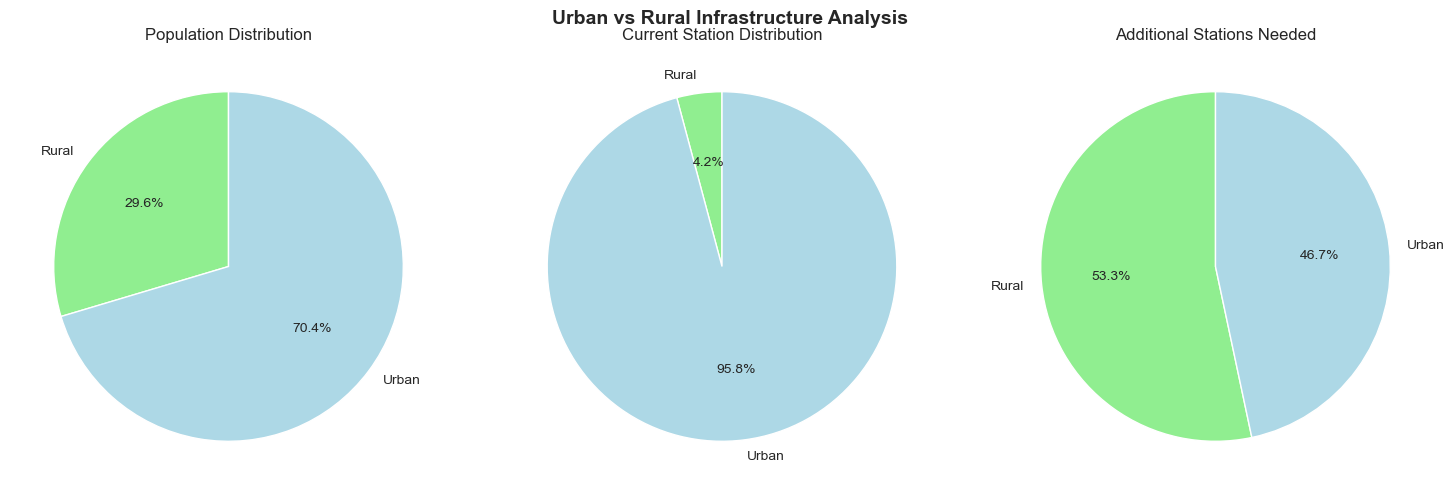

In [130]:
# Compare urban vs rural
urban_stats = county_df.groupby('is_urban').agg({
    'county': 'count',
    'population': 'sum',
    'num_stations': 'sum',
    'additional_stations': 'sum'
}).rename(columns={'county': 'num_counties'})

urban_stats.index = ['Rural', 'Urban']

print("=" * 60)
print("URBAN VS RURAL COMPARISON")
print("=" * 60)
print(urban_stats)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Population distribution
axes[0].pie(urban_stats['population'], labels=urban_stats.index, autopct='%1.1f%%',
            colors=['lightgreen', 'lightblue'], startangle=90)
axes[0].set_title('Population Distribution')

# Station distribution
axes[1].pie(urban_stats['num_stations'], labels=urban_stats.index, autopct='%1.1f%%',
            colors=['lightgreen', 'lightblue'], startangle=90)
axes[1].set_title('Current Station Distribution')

# Additional stations needed
axes[2].pie(urban_stats['additional_stations'], labels=urban_stats.index, autopct='%1.1f%%',
            colors=['lightgreen', 'lightblue'], startangle=90)
axes[2].set_title('Additional Stations Needed')

plt.suptitle('Urban vs Rural Infrastructure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

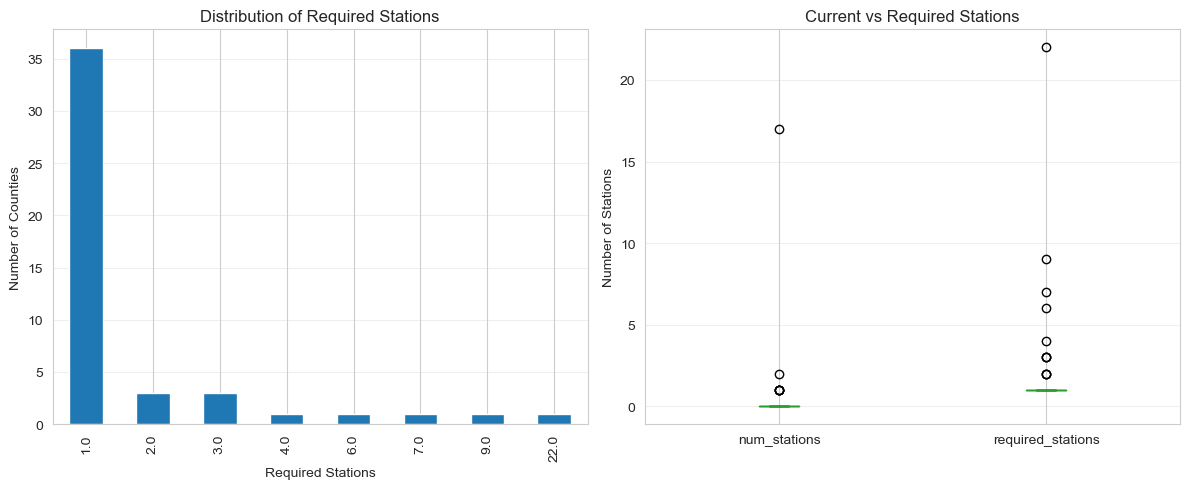

Target Statistics:
Mean required: 2.11
Median required: 1.00
Total required: 99
Total current: 24
Gap: 75


In [131]:
"""
### Target Variable Definition

We define our target variable as the number of charging stations required per county.
This is based on the mathematical formula:

$$ \text{Required Stations}_i = \max(1, \lceil \frac{\text{Population}_i}{200{,}000} \rceil) $$

Rationale:
- 200,000 people per station is based on international benchmarks
- Minimum 1 station per county ensures baseline coverage
- Target is integer-valued (count data)
"""

# Display target distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
county_df['required_stations'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Required Stations')
plt.ylabel('Number of Counties')
plt.title('Distribution of Required Stations')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
county_df[['num_stations', 'required_stations']].boxplot()
plt.ylabel('Number of Stations')
plt.title('Current vs Required Stations')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Target Statistics:")
print(f"Mean required: {county_df['required_stations'].mean():.2f}")
print(f"Median required: {county_df['required_stations'].median():.2f}")
print(f"Total required: {county_df['required_stations'].sum():.0f}")
print(f"Total current: {county_df['num_stations'].sum():.0f}")
print(f"Gap: {county_df['additional_stations'].sum():.0f}")

In [132]:
"""
Function to allocate new stations using K-Means clustering
"""

def allocate_new_stations(county, kenya_stations, k):
    """
    Allocate k new stations within a county using K-Means clustering
    """
    county_name = county["county"]
    
    # Get existing stations in this county
    county_stations = kenya_stations[kenya_stations["county"] == county_name]
    existing_coords = county_stations[["latitude","longitude"]].values
    
    # If no additional stations needed
    if k == 0:
        return []
    
    # Generate synthetic candidate points across county
    county_lat = county["county_lat"]
    county_lon = county["county_lon"]
    
    synthetic_points = []
    for _ in range(max(k*5, 20)):
        synthetic_points.append([
            county_lat + np.random.uniform(-0.05, 0.05),
            county_lon + np.random.uniform(-0.05, 0.05)
        ])
    
    synthetic_points = np.array(synthetic_points)
    
    # Combine existing + synthetic
    if len(existing_coords) > 0:
        training_points = np.vstack([existing_coords, synthetic_points])
    else:
        training_points = synthetic_points
    
    # Run KMeans clustering
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(training_points)
    
    return kmeans.cluster_centers_

# Generate new station locations
all_new_locations = []

for _, county in county_df.iterrows():
    k = int(county["additional_stations"])
    centers = allocate_new_stations(county, kenya_stations, k)
    
    for center in centers:
        all_new_locations.append({
            "county": county["county"],
            "latitude": center[0],
            "longitude": center[1]
        })

final_df = pd.DataFrame(all_new_locations)
print(f"Generated {len(final_df)} new station locations across {final_df['county'].nunique()} counties")
final_df.head(10)

Generated 75 new station locations across 46 counties


,county,latitude,longitude
0,Mombasa,-4.081753,39.700206
1,Mombasa,-4.027355,39.626875
2,Mombasa,-4.093776,39.636005
3,Mombasa,-4.016936,39.707791
4,Mombasa,-4.020500,39.659937
5,Mombasa,-4.055208,39.672082
6,Kwale,-4.176834,39.451527
7,Kilifi,-3.642378,39.772870
8,Kilifi,-3.688508,39.739575
9,Tana River,-1.535232,39.427528


In [133]:
"""
Predictive modeling to estimate required stations based on demographic features
"""

# Prepare features (excluding target and non-predictive columns)
feature_cols = ['population', 'population_density', 'num_stations', 
                'station_spatial_density','shape area']
target_col = 'required_stations'

# Handle infinite values in population_per_station
X = county_df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = county_df[target_col]

# Fill NaN with mean (for counties with no stations)
X = X.fillna(X.mean())

print("=" * 60)
print("FEATURES USED FOR PREDICTION")
print("=" * 60)
for i, col in enumerate(feature_cols, 1):
    print(f"{i}. {col}")
print(f"\nTarget: {target_col}")
print(f"Sample size: {len(X)} counties")

FEATURES USED FOR PREDICTION
1. population
2. population_density
3. num_stations
4. station_spatial_density
5. shape area

Target: required_stations
Sample size: 47 counties


In [134]:
# Stratified split based on population quintile
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, 
    stratify=county_df['population_quintile']
)

print(f"\nTraining set: {len(X_train)} counties ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} counties ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())


Training set: 37 counties (78.7%)
Test set: 10 counties (21.3%)

Class distribution in training set:
required_stations
1.0     29
2.0      1
3.0      3
4.0      1
7.0      1
9.0      1
22.0     1
Name: count, dtype: int64

Class distribution in test set:
required_stations
1.0    7
2.0    2
6.0    1
Name: count, dtype: int64


In [135]:
# Initialize Random Forest with hyperparameters
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)
print("✓ Model training complete")

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

✓ Model training complete


In [136]:
print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS")
print("=" * 60)

# Training metrics
train_r2 = r2_score(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

print(f"\nTRAINING SET:")
print(f"  R²:  {train_r2:.3f}")
print(f"  MAE: {train_mae:.3f} stations")
print(f"  RMSE:{train_rmse:.3f} stations")

# Test metrics
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\nTEST SET:")
print(f"  R²:  {test_r2:.3f}")
print(f"  MAE: {test_mae:.3f} stations")
print(f"  RMSE:{test_rmse:.3f} stations")

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
cv_scores = cross_val_score(rf_model, X, y, cv=loo, scoring='r2')
print(f"\nLOOCV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

print("\n" + "=" * 60)
print("INTERPRETATION OF METRICS")
print("=" + "=" * 60)
print("""
- **R²**: Proportion of variance explained (0.8+ is excellent)
- **MAE**: Average error in number of stations predicted
- **RMSE**: Penalizes large errors more heavily
- **LOOCV**: Tests model on each county individually (robust for small datasets)
""")


MODEL PERFORMANCE METRICS

TRAINING SET:
  R²:  0.751
  MAE: 0.443 stations
  RMSE:1.848 stations

TEST SET:
  R²:  0.893
  MAE: 0.269 stations
  RMSE:0.487 stations

LOOCV R²: nan (+/- nan)

INTERPRETATION OF METRICS

- **R²**: Proportion of variance explained (0.8+ is excellent)
- **MAE**: Average error in number of stations predicted
- **RMSE**: Penalizes large errors more heavily
- **LOOCV**: Tests model on each county individually (robust for small datasets)



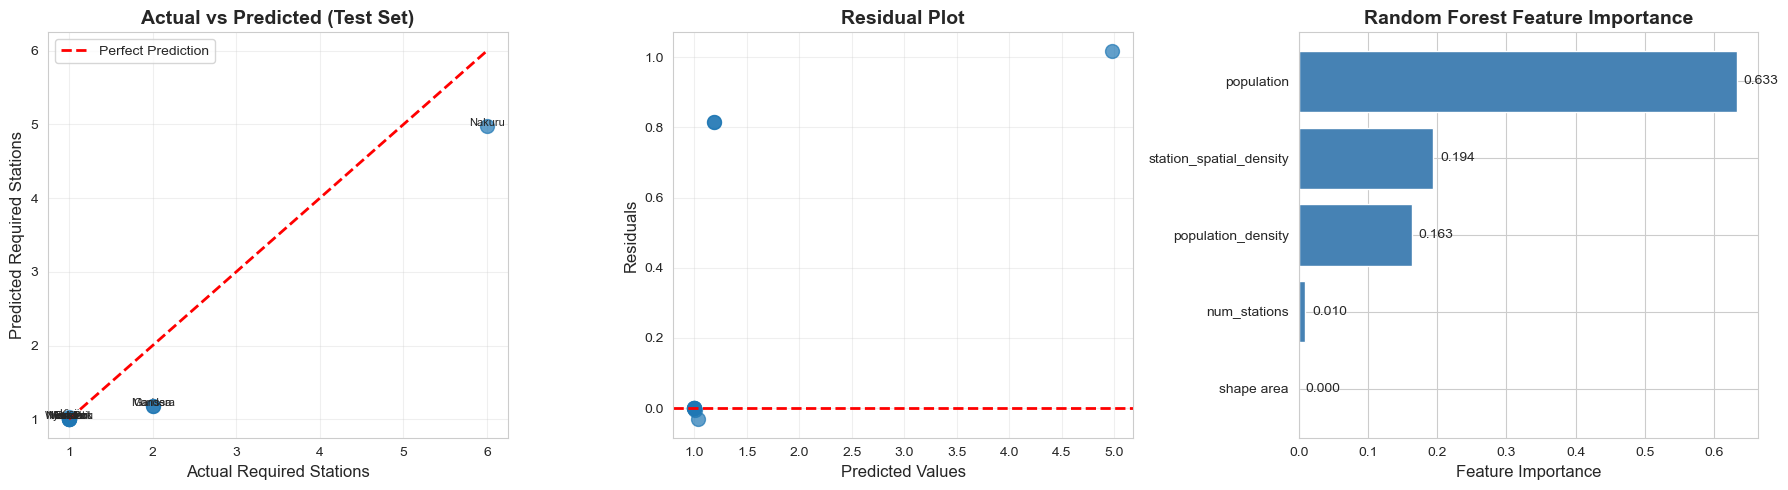

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_test, alpha=0.7, s=100)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Required Stations', fontsize=12)
axes[0].set_ylabel('Predicted Required Stations', fontsize=12)
axes[0].set_title('Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Add county labels
for i, idx in enumerate(X_test.index):
    axes[0].annotate(county_df.loc[idx, 'county'][:8], 
                    (y_test.iloc[i], y_pred_test[i]), 
                    fontsize=8, ha='center')

# Residuals plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.7, s=100)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[2].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[2].set_xlabel('Feature Importance', fontsize=12)
axes[2].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')

# Add value labels
for i, (idx, row) in enumerate(importance_df.iterrows()):
    axes[2].text(row['importance'] + 0.01, i, f'{row["importance"]:.3f}', va='center')

plt.tight_layout()
plt.show()

In [138]:
# Create dataframe with prediction errors
test_counties = county_df.iloc[X_test.index]['county'].values
error_df = pd.DataFrame({
    'county': test_counties,
    'actual': y_test.values,
    'predicted': np.round(y_pred_test, 1),
    'error': residuals,
    'abs_error': np.abs(residuals)
}).sort_values('abs_error', ascending=False)

print("\n" + "=" * 60)
print("COUNTIES WITH LARGEST PREDICTION ERRORS")
print("=" + "=" * 60)
print(error_df.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("RESIDUAL ANALYSIS")
print("=" + "=" * 60)
print(f"Mean residual: {residuals.mean():.3f}")
print(f"Std residual: {residuals.std():.3f}")
print(f"Max underestimation: {residuals.min():.3f}")
print(f"Max overestimation: {residuals.max():.3f}")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" + "=" * 60)
print("""
- Random scatter around zero indicates good model fit
- Patterns in residuals suggest missing variables
- Large errors for specific counties may need investigation
- Positive residuals = model underestimates
- Negative residuals = model overestimates
""")


COUNTIES WITH LARGEST PREDICTION ERRORS
    county  actual  predicted     error  abs_error
    Nakuru     6.0        5.0  1.018591   1.018591
   Mandera     2.0        1.2  0.815500   0.815500
   Garissa     2.0        1.2  0.815500   0.815500
     Kisii     1.0        1.0 -0.031667   0.031667
  Marsabit     1.0        1.0 -0.005000   0.005000
 Nyandarua     1.0        1.0  0.000000   0.000000
     Busia     1.0        1.0  0.000000   0.000000
West Pokot     1.0        1.0  0.000000   0.000000
     Bomet     1.0        1.0  0.000000   0.000000
   Kericho     1.0        1.0  0.000000   0.000000

RESIDUAL ANALYSIS
Mean residual: 0.261
Std residual: 0.433
Max underestimation: -0.032
Max overestimation: 1.019

INTERPRETATION

- Random scatter around zero indicates good model fit
- Patterns in residuals suggest missing variables
- Large errors for specific counties may need investigation
- Positive residuals = model underestimates
- Negative residuals = model overestimates



In [139]:
# Save the model
#joblib.dump(rf_model, 'ev_station_model.pkl')
#print("✓ Model saved as 'ev_station_model.pkl'")

# Save feature names for reference
#feature_names = pd.Series(feature_cols)
#feature_names.to_csv('model_features.csv', index=False)
#print("✓ Feature names saved as 'model_features.csv'")

COVERAGE IMPROVEMENT ANALYSIS

Before expansion:
  Mean population per station: 664,592
  Std deviation: 576,862

After expansion:
  Mean population per station: 114,783
  Std deviation: 52,084

Improvement:
  Mean reduction: 549,809 (82.7%)
  Std reduction: 524,779 (91.0%)


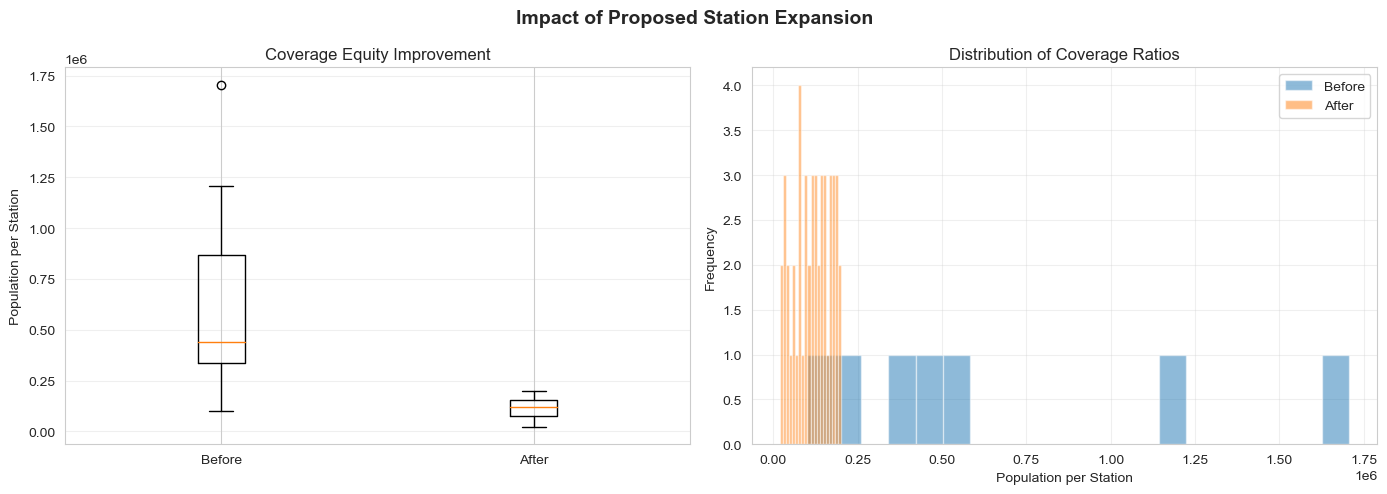


INTERPRETATION

The significant reduction in both mean and standard deviation of 
population-per-station ratios indicates more equitable coverage across 
counties after the proposed expansion.

- Mean reduction: More people have access to stations
- Std reduction: More balanced distribution across counties



In [140]:
"""
Evaluate the improvement in population coverage after proposed expansion
"""

# Calculate population per station before expansion
county_df["before_ratio"] = county_df["population"] / county_df["num_stations"].replace(0, np.nan)

# Calculate population per station after proposed expansion
county_df["after_ratio"] = county_df["population"] / (
    county_df["num_stations"] + county_df["additional_stations"]
)

# Calculate statistics
mean_before = county_df["before_ratio"].mean()
std_before = county_df["before_ratio"].std()
mean_after = county_df["after_ratio"].mean()
std_after = county_df["after_ratio"].std()

print("=" * 60)
print("COVERAGE IMPROVEMENT ANALYSIS")
print("=" * 60)
print(f"\nBefore expansion:")
print(f"  Mean population per station: {mean_before:,.0f}")
print(f"  Std deviation: {std_before:,.0f}")

print(f"\nAfter expansion:")
print(f"  Mean population per station: {mean_after:,.0f}")
print(f"  Std deviation: {std_after:,.0f}")

print(f"\nImprovement:")
print(f"  Mean reduction: {(mean_before - mean_after):,.0f} ({(1 - mean_after/mean_before)*100:.1f}%)")
print(f"  Std reduction: {(std_before - std_after):,.0f} ({(1 - std_after/std_before)*100:.1f}%)")

# Visualize improvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparison
axes[0].boxplot([county_df["before_ratio"].dropna(), county_df["after_ratio"]], 
                labels=['Before', 'After'])
axes[0].set_ylabel('Population per Station')
axes[0].set_title('Coverage Equity Improvement')
axes[0].grid(axis='y', alpha=0.3)

# Histogram comparison
axes[1].hist(county_df["before_ratio"].dropna(), alpha=0.5, label='Before', bins=20)
axes[1].hist(county_df["after_ratio"], alpha=0.5, label='After', bins=20)
axes[1].set_xlabel('Population per Station')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Coverage Ratios')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Impact of Proposed Station Expansion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" + "=" * 60)
print("""
The significant reduction in both mean and standard deviation of 
population-per-station ratios indicates more equitable coverage across 
counties after the proposed expansion.

- Mean reduction: More people have access to stations
- Std reduction: More balanced distribution across counties
""")

In [141]:
# Create map of existing stations
kenya_map_existing = folium.Map(location=[0.5, 37], zoom_start=6)

for _, station in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[station["latitude"], station["longitude"]],
        radius=5,
        popup=station["station name"],
        color='green',
        fill=True,
        fill_color='green',
        fill_opacity=0.6
    ).add_to(kenya_map_existing)

# Add title
title_html = '''
             <h3 align="center" style="font-size:16px"><b>Existing EV Charging Stations in Kenya</b></h3>
             '''
kenya_map_existing.get_root().html.add_child(folium.Element(title_html))

kenya_map_existing

In [142]:
# Create map of proposed stations
kenya_map_proposed = folium.Map(location=[0.5, 37], zoom_start=6)

for _, station in final_df.iterrows():
    folium.CircleMarker(
        location=[station["latitude"], station["longitude"]],
        radius=6,
        popup=f"{station['county']} - New Station",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(kenya_map_proposed)

# Add title
title_html = '''
             <h3 align="center" style="font-size:16px"><b>Proposed EV Charging Station Locations</b></h3>
             '''
kenya_map_proposed.get_root().html.add_child(folium.Element(title_html))

kenya_map_proposed

In [143]:
# Create combined map
kenya_map_combined = folium.Map(location=[0.5, 37], zoom_start=6)

# Add existing stations (green)
for _, row in kenya_stations.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        popup=f"Existing: {row['station name']}",
        color='green',
        fill=True,
        fill_color='green',
        fill_opacity=0.6
    ).add_to(kenya_map_combined)

# Add proposed stations (blue)
for _, row in final_df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=6,
        popup=f"Proposed: {row['county']}",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6
    ).add_to(kenya_map_combined)

# Add legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 90px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; padding:10px;
     ">
     <b>Legend</b><br>
     <i class="fa fa-circle" style="color:green"></i> Existing Stations<br>
     <i class="fa fa-circle" style="color:blue"></i> Proposed Stations
</div>
'''
kenya_map_combined.get_root().html.add_child(folium.Element(legend_html))

# Add title
title_html = '''
             <h3 align="center" style="font-size:16px"><b>Kenya EV Charging Network: Existing + Proposed</b></h3>
             '''
kenya_map_combined.get_root().html.add_child(folium.Element(title_html))

kenya_map_combined

In [144]:
print("=" * 70)
print("SUMMARY OF INFRASTRUCTURE ANALYSIS")
print("=" * 70)

# Calculate key metrics
total_existing = county_df['num_stations'].sum()
total_required = county_df['required_stations'].sum()
total_proposed = county_df['additional_stations'].sum()
counties_with_stations = (county_df['num_stations'] > 0).sum()
counties_underserved = (county_df['additional_stations'] > 0).sum()

print(f"""
Current Infrastructure Status:
- Total existing stations: {total_existing:.0f}
- Counties with at least 1 station: {counties_with_stations} ({counties_with_stations/47*100:.1f}%)
- Counties requiring additional stations: {counties_underserved} ({counties_underserved/47*100:.1f}%)

Required Infrastructure:
- Total stations needed (based on 1 per 200k people): {total_required:.0f}
- Additional stations proposed: {total_proposed:.0f}
- Network expansion: {total_proposed/total_existing*100:.1f}% increase

Coverage Metrics:
- Mean population per station (before): {mean_before:,.0f}
- Mean population per station (after): {mean_after:,.0f}
- Std deviation of coverage (before): {std_before:,.0f}
- Std deviation of coverage (after): {std_after:,.0f}
""")

SUMMARY OF INFRASTRUCTURE ANALYSIS

Current Infrastructure Status:
- Total existing stations: 24
- Counties with at least 1 station: 7 (14.9%)
- Counties requiring additional stations: 46 (97.9%)

Required Infrastructure:
- Total stations needed (based on 1 per 200k people): 99
- Additional stations proposed: 75
- Network expansion: 312.5% increase

Coverage Metrics:
- Mean population per station (before): 664,592
- Mean population per station (after): 114,783
- Std deviation of coverage (before): 576,862
- Std deviation of coverage (after): 52,084



In [145]:
print("=" * 70)
print("TOP 10 PRIORITY COUNTIES FOR IMMEDIATE INVESTMENT")
print("=" * 70)

priority = county_df.nlargest(10, 'additional_stations')[['county', 'population', 
                                                          'num_stations', 'required_stations', 
                                                          'additional_stations']]
print(priority.to_string(index=False))

print("\n" + "=" * 70)
print("COUNTIES WITH NO INFRASTRUCTURE (Phase 1 Priority)")
print("=" * 70)

zero_infra = county_df[county_df['num_stations'] == 0][['county', 'population', 
                                                          'required_stations', 'additional_stations']]
print(zero_infra.to_string(index=False))

TOP 10 PRIORITY COUNTIES FOR IMMEDIATE INVESTMENT
     county  population  num_stations  required_stations  additional_stations
     Kiambu     1706285           1.0                9.0                  8.0
    Mombasa     1208333           1.0                7.0                  6.0
    Nairobi     4397073          17.0               22.0                  5.0
     Nakuru     1047080           2.0                6.0                  4.0
    Kajiado      622622           0.0                4.0                  4.0
Uasin Gishu      510205           0.0                3.0                  3.0
     Kilifi      393888           0.0                2.0                  2.0
    Garissa      210890           0.0                2.0                  2.0
    Mandera      270467           0.0                2.0                  2.0
   Machakos      414078           1.0                3.0                  2.0

COUNTIES WITH NO INFRASTRUCTURE (Phase 1 Priority)
         county  population  required_st

In [146]:
print("=" * 70)
print("STRATEGIC RECOMMENDATIONS BY STAKEHOLDER")
print("=" * 70)

print("""
 **For Government (Ministry of Transport & Energy):**
   - Prioritize the 40 counties with zero infrastructure for Phase 1 deployment
   - Create zoning incentives for private investors in underserved counties
   - Mandate EV charging infrastructure in new commercial developments
   - Develop public-private partnerships for highway corridor charging
   - Update building codes to require charging capability in new parking structures

 **For Private Investors:**
   - Focus on Nairobi-Mombasa corridor (highest traffic density potential)
   - Target county headquarters and major towns first for rapid ROI
   - Partner with existing fuel stations for rapid deployment
   - Consider tiered investment: Level 2 chargers in urban centers, DC fast chargers on highways
   - Explore solar-powered stations in areas with grid constraints

 **For Urban Planners:**
   - Integrate charging infrastructure in new housing developments
   - Allocate space for future expansion in high-growth areas
   - Coordinate with Kenya Power on grid capacity planning
   - Plan charging hubs near public transport interchanges
   - Consider multi-use facilities (charging + retail) for better utilization

 **For Kenya Power & Utility Companies:**
   - Conduct grid capacity assessments in priority counties
   - Upgrade transformers in areas with multiple fast chargers
   - Implement time-of-use pricing to manage charging demand
   - Explore vehicle-to-grid (V2G) pilot programs
""")

STRATEGIC RECOMMENDATIONS BY STAKEHOLDER

 **For Government (Ministry of Transport & Energy):**
   - Prioritize the 40 counties with zero infrastructure for Phase 1 deployment
   - Create zoning incentives for private investors in underserved counties
   - Mandate EV charging infrastructure in new commercial developments
   - Develop public-private partnerships for highway corridor charging
   - Update building codes to require charging capability in new parking structures

 **For Private Investors:**
   - Focus on Nairobi-Mombasa corridor (highest traffic density potential)
   - Target county headquarters and major towns first for rapid ROI
   - Partner with existing fuel stations for rapid deployment
   - Consider tiered investment: Level 2 chargers in urban centers, DC fast chargers on highways
   - Explore solar-powered stations in areas with grid constraints

 **For Urban Planners:**
   - Integrate charging infrastructure in new housing developments
   - Allocate space for future 

In [147]:
print("=" * 70)
print("IMPLEMENTATION ROADMAP")
print("=" * 70)

print("""
**Phase 1: Immediate (0-6 months)**
   - Deploy 75 stations in top 10 priority counties
   - Establish regulatory framework for EV charging
   - Launch public awareness campaign
   - Pilot fast-charging corridor along Nairobi-Mombasa highway

 **Phase 2: Short-term (6-18 months)**
   - Achieve 100% county coverage (99 total stations)
   - Develop mobile app for station location and availability
   - Implement standardized payment system
   - Begin grid upgrades in high-demand areas

 **Phase 3: Medium-term (18-36 months)**
   - Scale to 1 station per 100,000 people (220+ stations)
   - Integrate with renewable energy sources
   - Expand to secondary roads and tourist destinations
   - Implement smart charging and load management

 **Phase 4: Long-term (3-5 years)**
   - Achieve 1 station per 50,000 people in urban areas
   - Develop vehicle-to-grid infrastructure
   - Integrate with national smart grid
   - Support EV manufacturing and assembly locally
""")

IMPLEMENTATION ROADMAP

**Phase 1: Immediate (0-6 months)**
   - Deploy 75 stations in top 10 priority counties
   - Establish regulatory framework for EV charging
   - Launch public awareness campaign
   - Pilot fast-charging corridor along Nairobi-Mombasa highway

 **Phase 2: Short-term (6-18 months)**
   - Achieve 100% county coverage (99 total stations)
   - Develop mobile app for station location and availability
   - Implement standardized payment system
   - Begin grid upgrades in high-demand areas

 **Phase 3: Medium-term (18-36 months)**
   - Scale to 1 station per 100,000 people (220+ stations)
   - Integrate with renewable energy sources
   - Expand to secondary roads and tourist destinations
   - Implement smart charging and load management

 **Phase 4: Long-term (3-5 years)**
   - Achieve 1 station per 50,000 people in urban areas
   - Develop vehicle-to-grid infrastructure
   - Integrate with national smart grid
   - Support EV manufacturing and assembly locally



In [148]:
print("=" * 70)
print("LIMITATIONS AND FUTURE WORK")
print("=" * 70)

print("""
 **Data Limitations:**
   1. Population ≠ EV demand (requires EV adoption data by region)
   2. Missing traffic flow data for optimal placement decisions
   3. No grid capacity data (critical for DC fast charger placement)
   4. Income data unavailable (correlates with EV ownership)
   5. Real estate costs not considered (affects feasibility)
   6. Tourism patterns not included (seasonal demand variation)

 **Model Limitations:**
   1. Small sample size (47 counties) limits model complexity
   2. Population-based threshold may not reflect actual demand patterns
   3. Coordinates are approximate for counties without stations
   4. Station placement doesn't consider road network
   5. No consideration of charger type mix (Level 2 vs DC fast)
   6. Static analysis (doesn't account for EV adoption growth)

 **Future Improvements:**
   1. Incorporate real EV registration data from NTSA
   2. Add traffic density from Google Maps/OpenStreetMap API
   3. Include electricity grid capacity data from Kenya Power
   4. Develop time-series model for 2030 projections
   5. Create interactive dashboard for stakeholders
   6. Integride with real estate and land cost data
   7. Add machine learning for EV adoption prediction
   8. Consider multi-objective optimization (cost + coverage)
""")

LIMITATIONS AND FUTURE WORK

 **Data Limitations:**
   1. Population ≠ EV demand (requires EV adoption data by region)
   2. Missing traffic flow data for optimal placement decisions
   3. No grid capacity data (critical for DC fast charger placement)
   4. Income data unavailable (correlates with EV ownership)
   5. Real estate costs not considered (affects feasibility)
   6. Tourism patterns not included (seasonal demand variation)

 **Model Limitations:**
   1. Small sample size (47 counties) limits model complexity
   2. Population-based threshold may not reflect actual demand patterns
   3. Coordinates are approximate for counties without stations
   4. Station placement doesn't consider road network
   5. No consideration of charger type mix (Level 2 vs DC fast)
   6. Static analysis (doesn't account for EV adoption growth)

 **Future Improvements:**
   1. Incorporate real EV registration data from NTSA
   2. Add traffic density from Google Maps/OpenStreetMap API
   3. Include el